## Non-linear multiple regression to estimate W*i
Using tau*i, and antecedent flow duration and magnitude

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from pysr import PySRRegressor

[juliapkg] Found dependencies: c:\users\huck4481\appdata\local\programs\python\python313\lib\site-packages\juliacall\juliapkg.json
[juliapkg] Found dependencies: c:\users\huck4481\appdata\local\programs\python\python313\lib\site-packages\juliapkg\juliapkg.json
[juliapkg] Found dependencies: c:\users\huck4481\appdata\local\programs\python\python313\lib\site-packages\pysr\juliapkg.json
[juliapkg] Locating Julia 1.10.3 - 1.11
[juliapkg] Querying Julia versions from https://julialang-s3.julialang.org/bin/versions.json
[juliapkg] WARNING: About to install Julia 1.11.7 to C:\Users\huck4481\.julia\environments\pyjuliapkg\pyjuliapkg\install.
[juliapkg]   If you use juliapkg in more than one environment, you are likely to
[juliapkg]   have Julia installed in multiple locations. It is recommended to
[juliapkg]   install JuliaUp (https://github.com/JuliaLang/juliaup) or Julia
[juliapkg]   (https://julialang.org/downloads) yourself.
[juliapkg] Downloading Julia from https://julialang-s3.julialang.

Load Data

In [2]:
df = pd.read_csv("16mm.csv").dropna()  
X_raw = df[['tau*i', 'magnitude', 'duration']].values
y = df['w*i'].values

Functions

In [ ]:
def adj_r2(r2, n, k):
    return 1 - (1-r2)*(n-1)/(n-k-1)

def evaluate_model(name, y_true, y_pred, k):
    r2 = r2_score(y_true, y_pred)
    ar2 = adj_r2(r2, len(y_true), k)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {"Model": name, "R2": r2, "AdjR2": ar2, "RMSE": rmse}

def plot_comparison(y_true, y_pred, title):
    plt.figure(figsize=(3,3))
    plt.scatter(y_true, y_pred, color='black', s=15, alpha=0.7, zorder=2)
    minv, maxv = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
    plt.plot([minv, maxv], [minv, maxv], color='gray', zorder=1)  # 1:1 line
    plt.xlabel("Measured Wi*")
    plt.ylabel("Predicted Wi*")
    plt.title(title)
    plt.show()

def plot_comparison2(y_true, y_pred, title, X_raw=None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    
    # first subplot: actual data and predictions vs tau*i
    if X_raw is not None:
        tau_star = X_raw[:, 0]  # first column is tau*i
        ax1.scatter(tau_star, y_true, color='blue', s=15, alpha=0.7, label='Measured', zorder=2)
        ax1.scatter(tau_star, y_pred, color='red', s=15, alpha=0.7, label='Predicted', zorder=2)
        ax1.set_xlabel("τ*i")
        ax1.set_ylabel("W*i")
        ax1.legend()
        ax1.set_title(f"{title} - Data vs Fit")
    
    # second subplot: measured vs predicted (original plot)
    ax2.scatter(y_true, y_pred, color='black', s=15, alpha=0.7, zorder=2)
    minv, maxv = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
    ax2.plot([minv, maxv], [minv, maxv], color='gray', zorder=1)  # 1:1 line
    ax2.set_xlabel("Measured W*i")
    ax2.set_ylabel("Predicted W*i")
    ax2.set_title(f"{title} - Measured vs Predicted")
    
    plt.tight_layout()
    plt.show()

# Parametric Non-Linear Regressions 

### Polynomial Regression

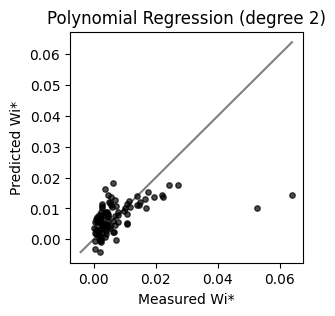

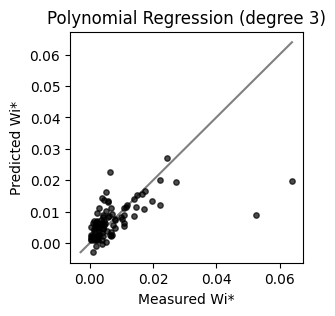

In [ ]:
results = []
for degree in [2, 3]:
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X_raw)
    model = LinearRegression()
    model.fit(X_poly, y)
    y_pred = model.predict(X_poly)
    metrics = evaluate_model(f"Polynomial deg={degree}", y, y_pred, X_poly.shape[1])
    results.append(metrics)
    plot_comparison(y, y_pred, f"Polynomial Regression (degree {degree})")

### Log Regression
Wi* = a + b ln(ti) + c ln(mag) + d ln(dur)

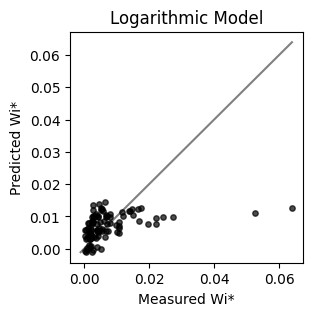

In [21]:
X_log = np.log(X_raw)
log_model = LinearRegression()
log_model.fit(X_log, y)
y_log_pred = log_model.predict(X_log)
metrics = evaluate_model("Logarithmic", y, y_log_pred, X_log.shape[1])
results.append(metrics)
plot_comparison(y, y_log_pred, "Logarithmic Model")

### Exponential Regression
Wi* = exp(a + b ti + c mag + d dur)

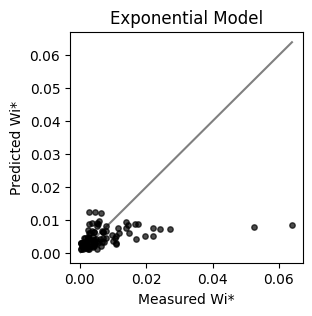

In [ ]:
y_log = np.log(y)
exp_model = LinearRegression()
exp_model.fit(X_raw, y_log)
y_exp_pred = np.exp(exp_model.predict(X_raw))
metrics = evaluate_model("Exponential", y, y_exp_pred, X_raw.shape[1])
results.append(metrics)
plot_comparison(y, y_exp_pred, "Exponential Model")

### Power Regression
Wi* = a * ti^b * mag^c * dur^d

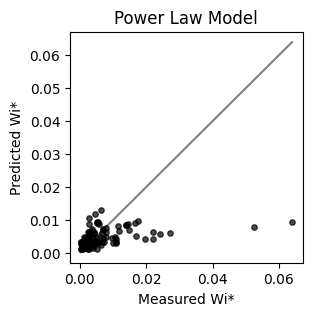

In [24]:
X_power = np.log(X_raw)
y_power_log = np.log(y)
power_model = LinearRegression()
power_model.fit(X_power, y_power_log)
y_power_pred = np.exp(power_model.predict(X_power))
metrics = evaluate_model("Power Law", y, y_power_pred, X_power.shape[1])
results.append(metrics)
plot_comparison(y, y_power_pred, "Power Law Model")

### Summary Table

In [25]:
result_df = pd.DataFrame(results)
print("\nMODEL PERFORMANCE:")
print(result_df.sort_values("AdjR2", ascending=False))


MODEL PERFORMANCE:
              Model        R2     AdjR2      RMSE
0  Polynomial deg=2  0.266668  0.181397  0.008037
1  Polynomial deg=3  0.344382  0.171851  0.007599
2       Logarithmic  0.162783  0.135776  0.008587
4         Power Law  0.087788  0.058362  0.008964
5         Power Law  0.087788  0.058362  0.008964
3       Exponential  0.085839  0.056350  0.008973


# Trying Symbolic Regression (SR)

In [33]:
X = df[['tau*i', 'magnitude', 'duration']].values
y = df['w*i'].values

model = PySRRegressor(
    niterations=2000,          # increase for better equations
    unary_operators=[
        "log",     
        "exp",
        "sqrt",
    ],
    binary_operators=[
        "+", "-", "*", "/", "pow"
    ],
    elementwise_loss="loss(x, y) = (x - y)^2",  # MSE loss
    maxsize=12,                 # maximum equation complexity
)

In [34]:
model.fit(X, y)

c:\Users\huck4481\AppData\Local\Programs\Python\Python313\Lib\site-packages\pysr\sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
Compiling Julia backend...
c:\Users\huck4481\AppData\Local\Programs\Python\Python313\Lib\site-packages\pysr\sr.py:96: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (-1) but only powers such as a constant or variable (1). For more tips, please see https://ai.damtp.cam.ac.uk/pysr/tuning/
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 2.980e+05
Progress: 1846 / 62000 total iterations (2.977%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           8.808e-05  0.000e+00  y = 0.0070932
3           7.371e-05  8.903e-02  y = x₀ + -0.046233
4           7.371e-05  1.156e-05  y = log(x₀ + 0.9538)
5           7.369e-05  3.191e-04  y = (x₀ * 0.96049) + -0.044126
7           7.335e-05  2.316e-03  y = (x₀ + -0.044721) / log(log(x₂))
8           7.233e-05  1.397e-02  y = exp(3.2916 / x₂) * (x₀ + -0.046998)
9           7.232e-05  1.855e-04  y = (x₀ + -0.046997) / (x₁ ^ (-0.37811 / x₂))
10          7.171e-05  8.403e-03  y = exp(4.9528 / x₂) * ((x₀ * 0.79541) + -0.036568)
11          7.169e-05  2.306e-04  y = (x₀ + -0.046874) / (x₁ ^ ((-4.1666 / x₂) / x₂))
12          7.169e-05  7.165e-05  y = ((-0.04

[ Info: Final population:
[ Info: Results saved to:


,model_selection,'best'
,binary_operators,"['+', '-', ...]"
,unary_operators,"['log', 'exp', ...]"
,expression_spec,None
,niterations,2000
,populations,31
,population_size,27
,max_evals,None
,maxsize,12
,maxdepth,None
,warmup_maxsize_by,None


  - outputs\20251209_185905_ZrjXEz\hall_of_fame.csv


In [35]:
# show best discovered equations
print(model)

# predictions and metrics
y_pred = model.predict(X)
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print("\nMODEL PERFORMANCE:")
print("R² =", r2)
print("RMSE =", rmse)

PySRRegressor.equations_ = [
	    pick     score                                           equation  \
	0         0.000000                                       0.0070931674   
	1   >>>>  0.089034                                   x0 + -0.04623276   
	2         0.000011                               log(x0 + 0.95379925)   
	3         0.000398                      (2.4985266 ^ x0) + -1.0429562   
	4         0.000007               (exp(x0) * 0.91124827) + -0.95407474   
	5         0.021069            (x0 + -0.046849217) + (0.56211734 ^ x2)   
	6         0.007005          exp(0.89981085 ^ x2) * (x0 + -0.04682819)   
	7         0.014704       (0.74886376 ^ (x1 / x2)) + (x0 + -0.0468183)   
	8         0.007670  (exp(0.88433653 ^ (x1 / x2)) * x0) + -0.047066767   
	9         0.008748  x0 + ((x0 ^ (1.0298055 ^ (x1 / x2))) + -0.0470...   
	10        0.023046  (x0 + -0.047044955) * exp((0.87266105 ^ (x1 / ...   
	
	        loss  complexity  
	0   0.000088           1  
	1   0.000074           3

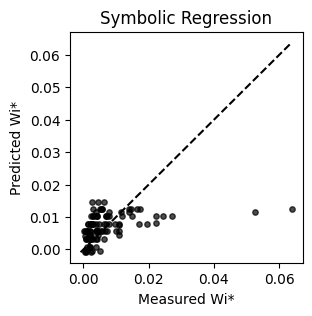

In [40]:
# plot measured vs predicted
plt.figure(figsize=(3,3))
plt.scatter(y, y_pred, label="Predicted", zorder=2, color='black', s=15, alpha=0.7)
minv, maxv = min(y.min(), y_pred.min()), max(y.max(), y_pred.max())
plt.plot([minv, maxv], [minv, maxv], 'k--', zorder=1)
plt.xlabel("Measured Wi*")
plt.ylabel("Predicted Wi*")
plt.title("Symbolic Regression")
plt.show()

In [37]:
# best equation (human-readable)
print("\nBest equation:", model.get_best())


Best equation: complexity                                      3
loss                                     0.000074
equation                         x0 + -0.04623276
score                                    0.089034
sympy_format                      x0 - 0.04623276
lambda_format    PySRFunction(X=>x0 - 0.04623276)
Name: 1, dtype: object
